In [2]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from scipy.signal import windows

import itertools

D = 1

N = 5000
L = 5.*np.pi

grid_dims = [N for _ in range(D)]

phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi

dk = twopi/L

dx = L/N

D = 1


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:79: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice


Text(0.5, 1.0, 'Structure function')

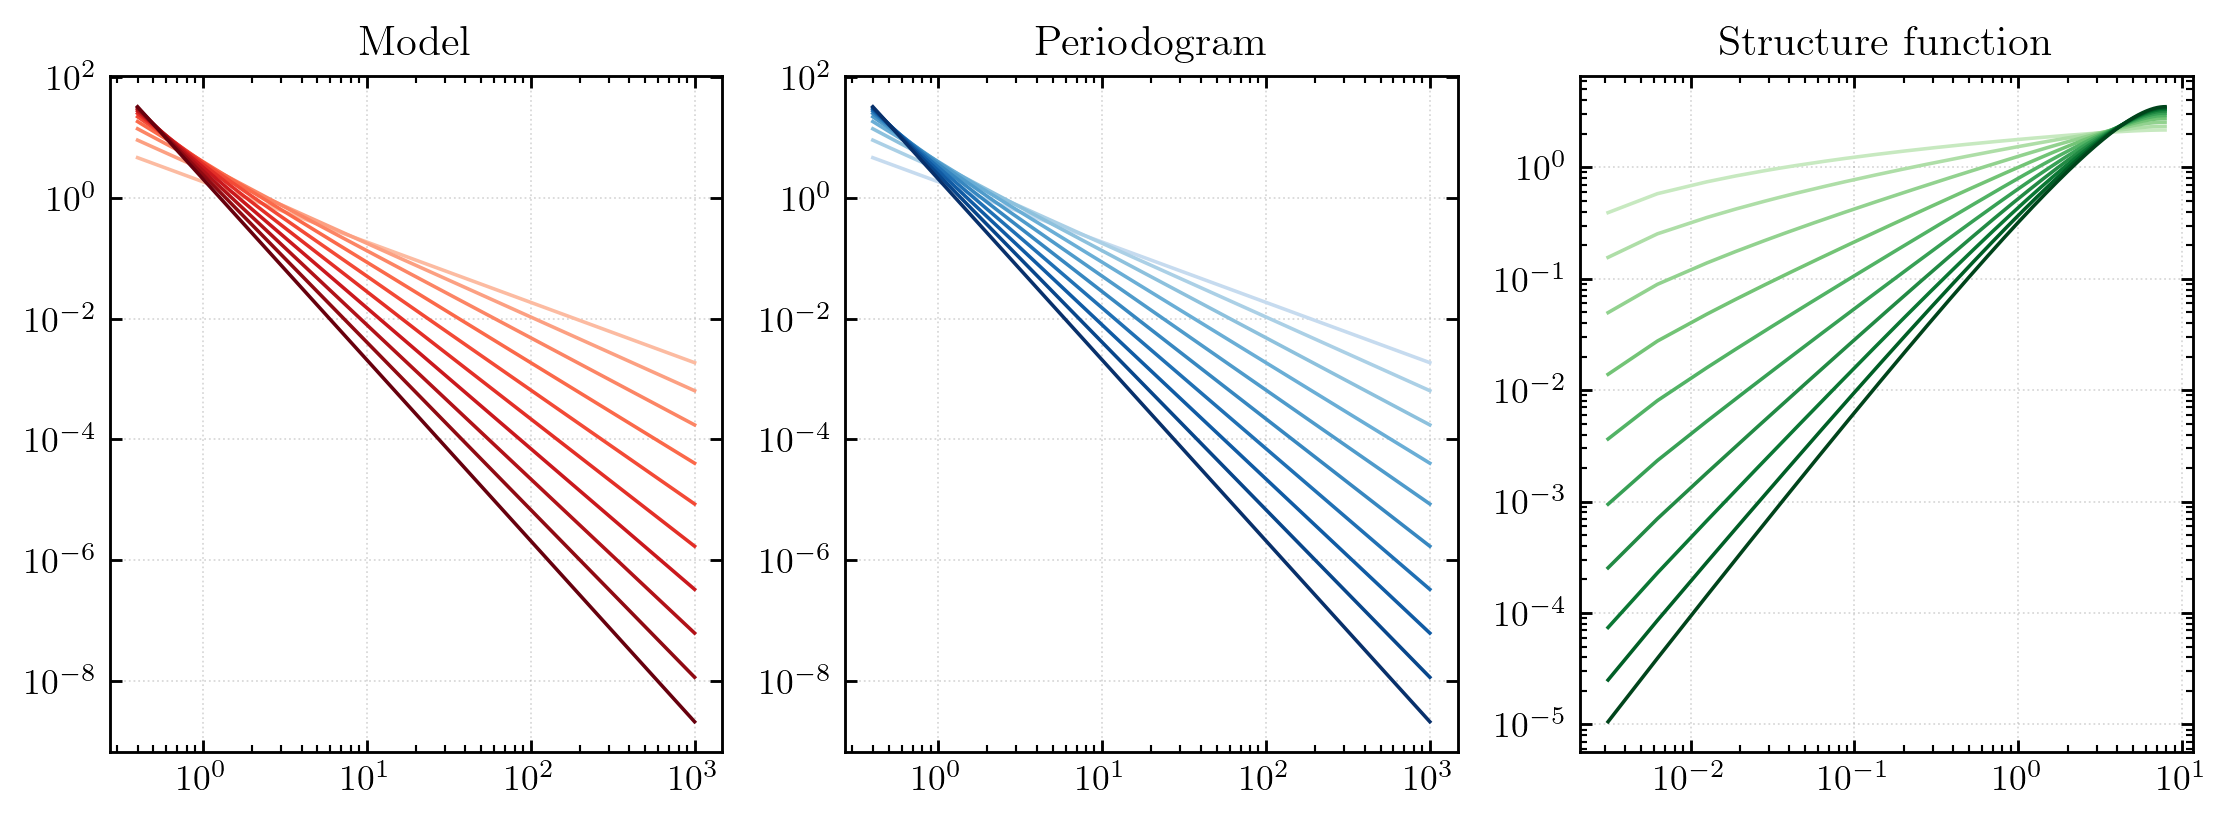

In [3]:
amin, amax = -(D+2.), -D
NUM = 10
alphas = np.linspace(amax, amin, NUM)

np.random.seed(1234)
fields = []

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), gfunc='pure_pow'))

models = []
Pspecs = []
Ssf = []
Sacf = []
all_acf = []
all_sf = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    _km, _fekm, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims,
        ignore_nan=True, nan_small=True, max_bin=np.pi*N/L, min_bin=dk)
        #kwargs={'ignore_nan': True, 'nan_small': True, 'max_bin': np.pi*N/L, 'min_bin': dk})
    Pspecs.append((_km, _fekm))

    kmesh = spectra_base.wavenumber_mesh(kD)
    fekD_model = funcs.pure_pow(kmesh, (alphas[i],))
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, _ = spectra_base.spectrum_integrate(kD, fekD_model, spec_type='omni', lenn=phys_dims,
        ignore_nan=True, nan_small=True, max_bin=np.pi*N/L, min_bin=dk)
    models.append((k_model, fek_model))

    lv = statfunc_base.get_all_lagvecs([2*n for n in grid_dims])
    acf = corr.process_lags(f, f, lv, lenn=grid_dims, shape=[2*n for n in grid_dims], periodic=True)
    all_acf.append(acf)
    lvm = statfunc_base.get_lagvec_magnitude_array([2*n for n in grid_dims]) * dx
    l, aacf, w = statistics_base.bin_data(
        lvm, acf, bin_func=np.nanmean, cut_excess=True, nan_small=True, ignore_nan=True,
        min_bin=0., bin_loc='true_center', max_bin=L/2)
    Sacf.append((l, aacf))

    lv = statfunc_base.get_all_lagvecs([2*n for n in grid_dims])
    sf = strfn.process_lags(f, f, lv, lenn=grid_dims, shape=[2*n for n in grid_dims], orders=[2], periodic=True)[0]
    lvm = statfunc_base.get_lagvec_magnitude_array([2*n for n in grid_dims]) * dx
    l, sf2, w = statistics_base.bin_data(
        lvm, sf, bin_func=np.nanmean, cut_excess=True, nan_small=True, ignore_nan=True,
        min_bin=0., bin_loc='true_center', max_bin=L/2)
    Ssf.append((l, sf2))

cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
cols1 = plt.cm.Reds(np.linspace(0.25, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))

fig, ax = plt.subplots(1, 3, figsize=(3.5*3., 3.5), dpi=256)

for i, a in enumerate(alphas):
    ax[0].plot(models[i][0], models[i][1], linewidth=1., color=cols1[i])
    ax[1].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color=cols2[i])
    ax[2].plot(Ssf[i][0], Ssf[i][1], linewidth=1., color=cols3[i])

for axx in ax:
    axx.set_xscale('log')
    axx.set_yscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_title('Model')
ax[1].set_title('Periodogram')
ax[2].set_title('Structure function')


In [4]:

def omni_spectrum(ell, sf2, a, b):

    dS = np.gradient(sf2)
    dell = np.gradient(ell)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a * (2.*np.pi/dk)
    kk = b / ell

    return kk[::-1], fek[::-1]

Especs_11 = []
Especs_pipi = []
Especs_2pi2pi = []
for i, a in enumerate(alphas):
    Especs_11.append(omni_spectrum(*Ssf[i], 1., 1.))
    Especs_pipi.append(omni_spectrum(*Ssf[i], np.pi, np.pi))
    Especs_2pi2pi.append(omni_spectrum(*Ssf[i], 2.*np.pi, 2.*np.pi))

from scipy.interpolate import interp1d
def interpolate(k_sf, fek_sf, k_interp):
    f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')
    fek_new = f_int(np.log10(k_interp))
    return 10**fek_new


/tmp/ipykernel_13887/1544057829.py:21: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


(0.01, 100.0)

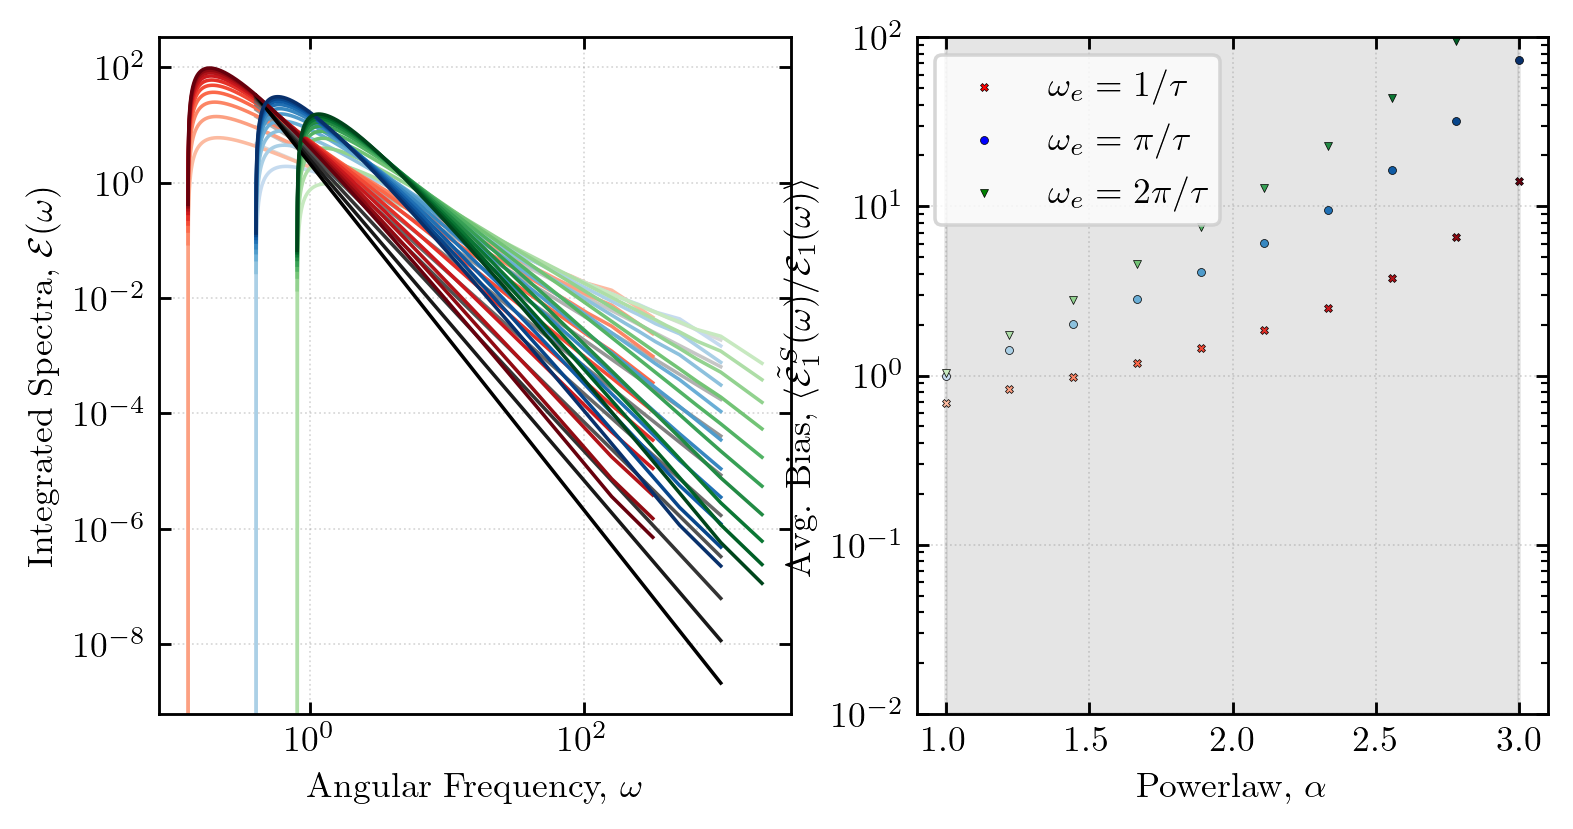

In [5]:

fig, ax = plt.subplots(1, 2, figsize=(3.5*2, 3.5), dpi=256)

for i, a in enumerate(alphas):
    if a == 0.:
        continue
    ax[0].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color=cols[i])
    ax[0].plot(Especs_11[i][0], Especs_11[i][1], linewidth=1., color=cols1[i])
    ax[0].plot(Especs_pipi[i][0], Especs_pipi[i][1], linewidth=1., color=cols2[i])
    ax[0].plot(Especs_2pi2pi[i][0], Especs_2pi2pi[i][1], linewidth=1., color=cols3[i])
    
    fek_11 = interpolate(*Especs_11[i], Pspecs[i][0])
    fek_pipi = interpolate(*Especs_pipi[i], Pspecs[i][0])
    fek_2pi2pi = interpolate(*Especs_2pi2pi[i], Pspecs[i][0])

    ax[1].scatter(-a, np.nanmean(fek_11/Pspecs[i][1]), marker='X', s=5., color=cols1[i], zorder=2, linewidth=0.2, edgecolor='black')
    ax[1].scatter(-a, np.nanmean(fek_pipi/Pspecs[i][1]), marker='o', s=5., color=cols2[i], zorder=2, linewidth=0.2, edgecolor='black')
    ax[1].scatter(-a, np.nanmean(fek_2pi2pi/Pspecs[i][1]), marker='v', s=5., color=cols3[i], zorder=2, linewidth=0.2, edgecolor='black')

ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].set_yscale('log')

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[1].axvspan(1., 3., alpha=0.2, color='gray', zorder=0)

ax[0].set_ylabel(r'Integrated Spectra, $\mathcal{E}(\omega)$')
ax[0].set_xlabel('Angular Frequency, $\omega$')
ax[1].set_ylabel(r'Avg. Bias, $\langle \tilde{\mathcal{E}}^S_1(\omega)/\mathcal{E}_1(\omega) \rangle$')
ax[1].set_xlabel('Powerlaw, $\\alpha$')

ax[1].scatter([], [], color='red', label=r'$\omega_e = 1/\tau$', marker='X', edgecolor='black', linewidth=0.2, s=5.)
ax[1].scatter([], [], color='blue', label=r'$\omega_e = \pi/\tau$', marker='o', edgecolor='black', linewidth=0.2, s=5.)
ax[1].scatter([], [], color='green', label=r'$\omega_e = 2 \pi/\tau$', marker='v', edgecolor='black', linewidth=0.2, s=5.)

ax[1].legend()
ax[1].set_ylim((1e-2, 1e2))


/tmp/ipykernel_13887/1544057829.py:21: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


(0.01, 100000.0)

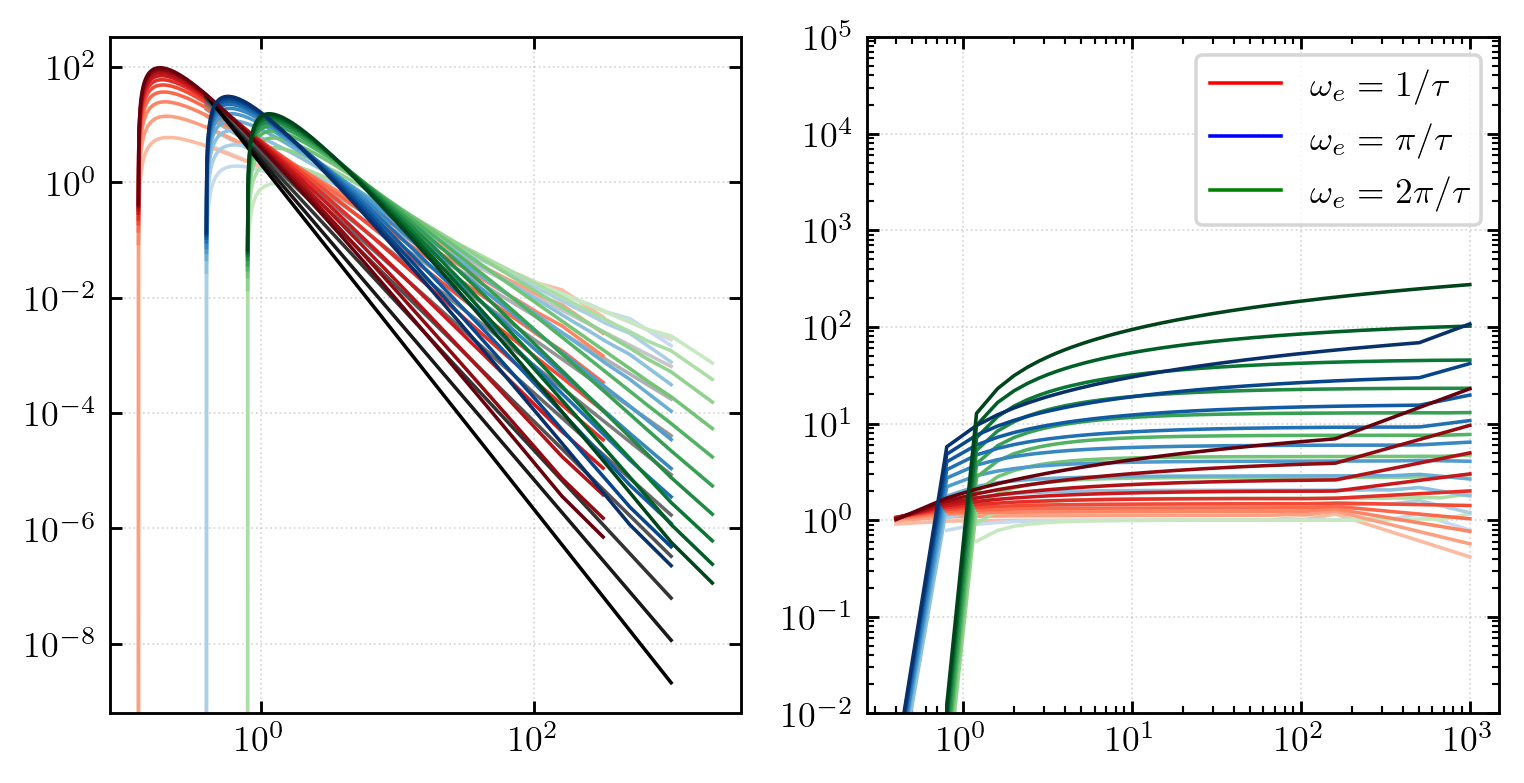

In [6]:

fig, ax = plt.subplots(1, 2, figsize=(3.5*2, 3.5), dpi=256)

for i, a in enumerate(alphas):
    if a == 0.:
        continue

    ax[0].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color=cols[i])
    ax[0].plot(Especs_11[i][0], Especs_11[i][1], linewidth=1., color=cols1[i])
    ax[0].plot(Especs_pipi[i][0], Especs_pipi[i][1], linewidth=1., color=cols2[i])
    ax[0].plot(Especs_2pi2pi[i][0], Especs_2pi2pi[i][1], linewidth=1., color=cols3[i])
    
    fek_11 = interpolate(*Especs_11[i], Pspecs[i][0])
    fek_pipi = interpolate(*Especs_pipi[i], Pspecs[i][0])
    fek_2pi2pi = interpolate(*Especs_2pi2pi[i], Pspecs[i][0])

    ax[1].plot(Pspecs[i][0], fek_11/Pspecs[i][1], linewidth=1., color=cols1[i])
    ax[1].plot(Pspecs[i][0], fek_pipi/Pspecs[i][1], linewidth=1., color=cols2[i])
    ax[1].plot(Pspecs[i][0], fek_2pi2pi/Pspecs[i][1], linewidth=1., color=cols3[i])

for axx in ax:
    axx.set_xscale('log')
    axx.set_yscale('log')
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[1].plot([], [], linewidth=1., color='red', label=r'$\omega_e = 1/\tau$')
ax[1].plot([], [], linewidth=1., color='blue', label=r'$\omega_e = \pi/\tau$')
ax[1].plot([], [], linewidth=1., color='green', label=r'$\omega_e = 2 \pi/\tau$')

ax[1].legend()

ax[1].set_ylim((1e-2, 1e5))


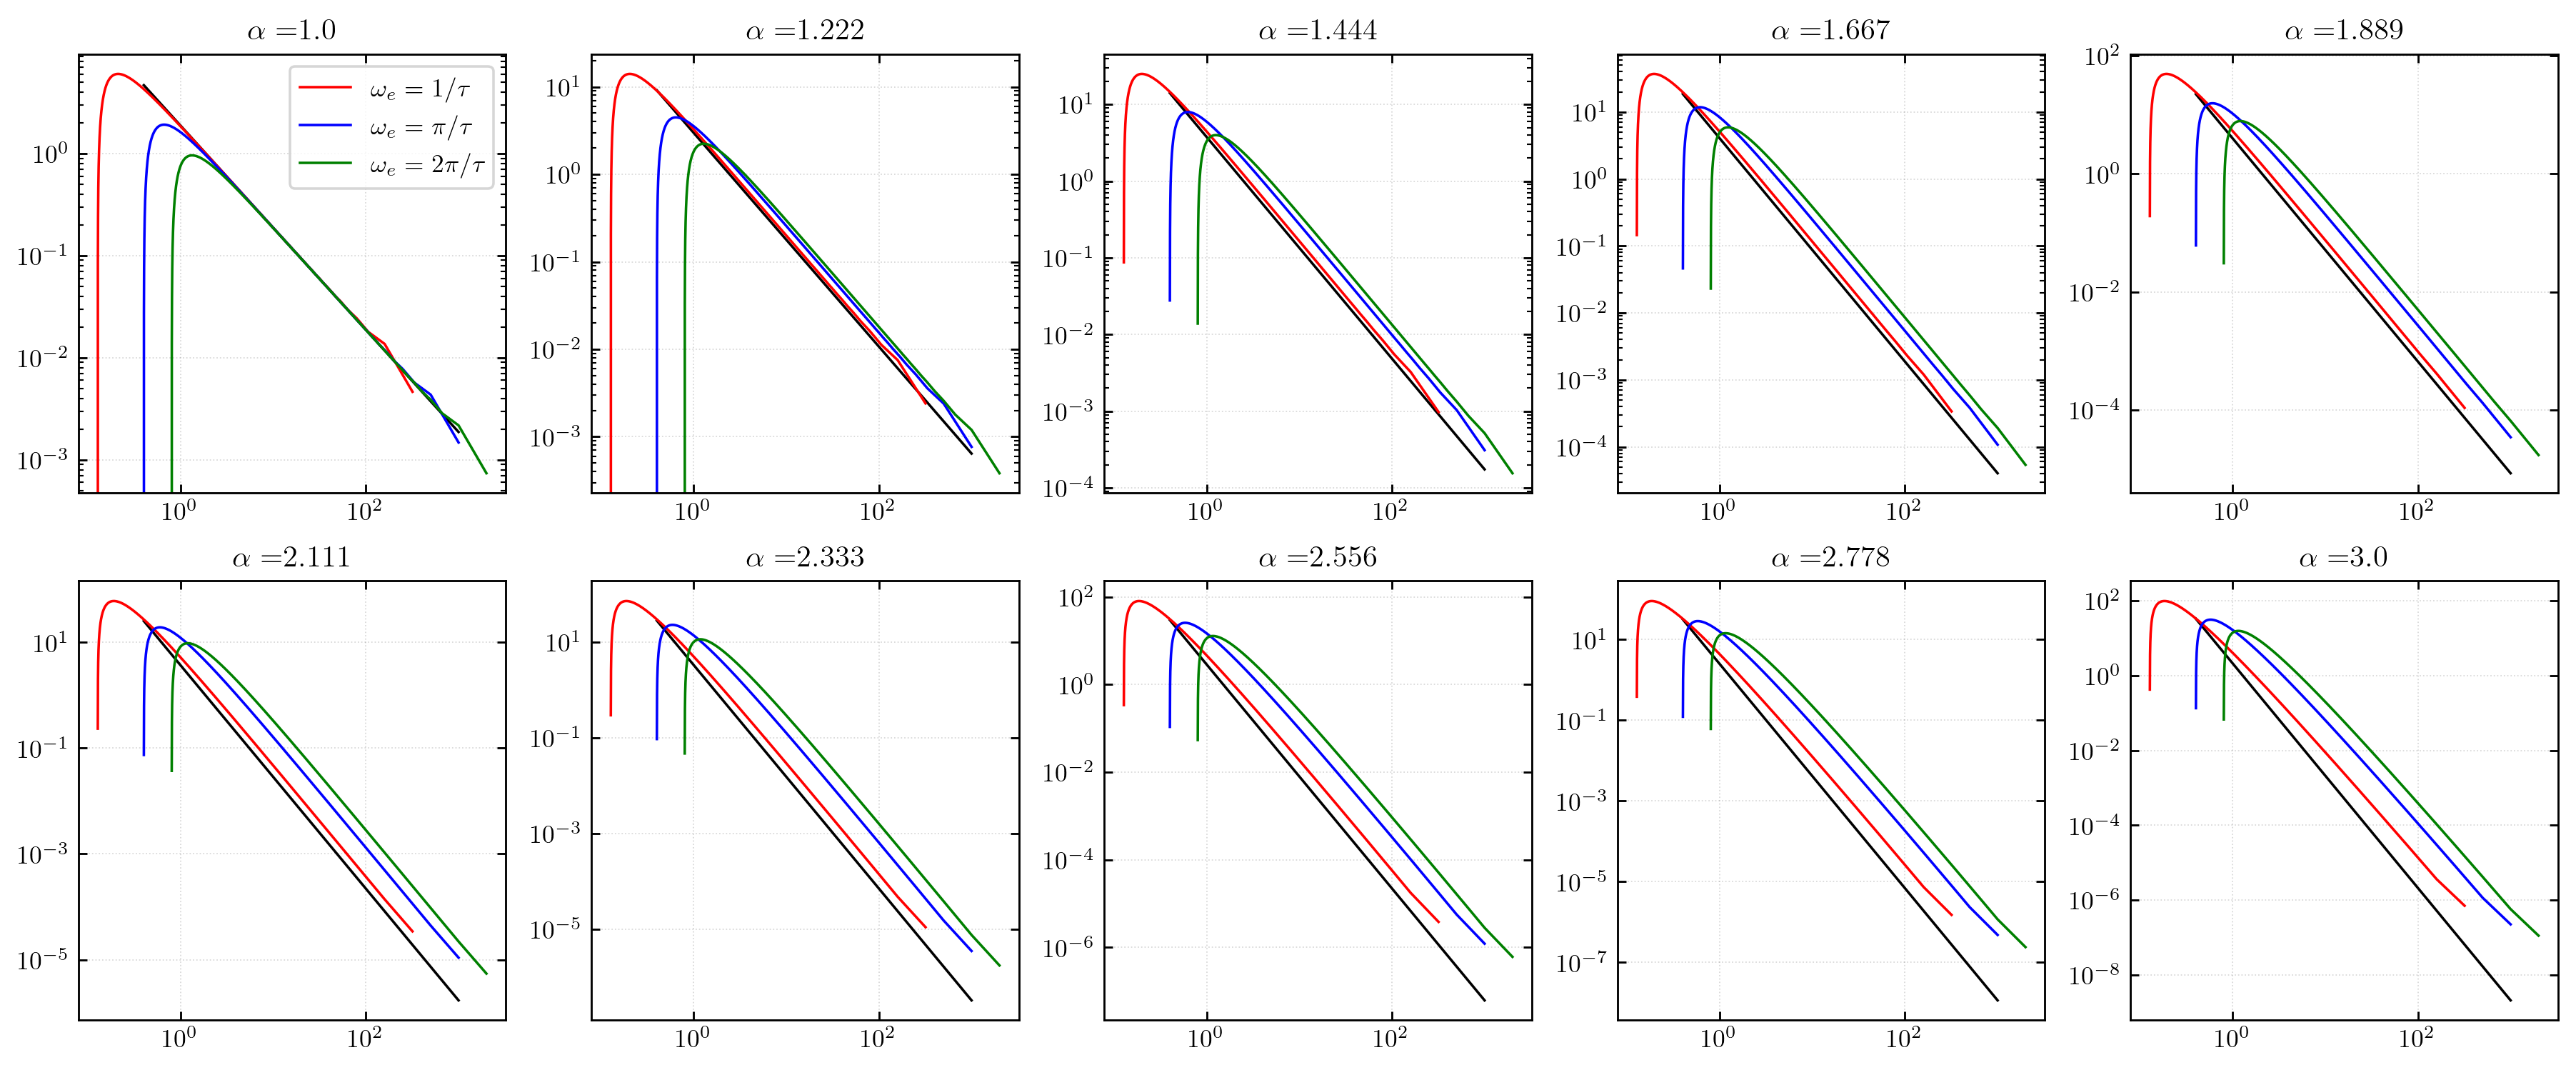

In [7]:

fig, ax = plt.subplots(2, 5, figsize=(3.5*5, 3.5*2), dpi=256)

i = 0
for j in range(2):
    for k in range(5):
        a = alphas[i]

        ax[j][k].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color='black')
        ax[j][k].plot(Especs_11[i][0], Especs_11[i][1], linewidth=1., color='red')
        ax[j][k].plot(Especs_pipi[i][0], Especs_pipi[i][1], linewidth=1., color='blue')
        ax[j][k].plot(Especs_2pi2pi[i][0], Especs_2pi2pi[i][1], linewidth=1., color='green')

        ax[j][k].set_title(r'$\alpha=$%s' % -a.round(decimals=3))

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0][0].plot([], [], linewidth=1., color='red', label=r'$\omega_e = 1/\tau$')
ax[0][0].plot([], [], linewidth=1., color='blue', label=r'$\omega_e = \pi/\tau$')
ax[0][0].plot([], [], linewidth=1., color='green', label=r'$\omega_e = 2 \pi/\tau$')
ax[0][0].legend()

# ax[1].set_ylim((1e-2, 1e5))


/tmp/ipykernel_13887/1544057829.py:21: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


(1e-10, 10.0)

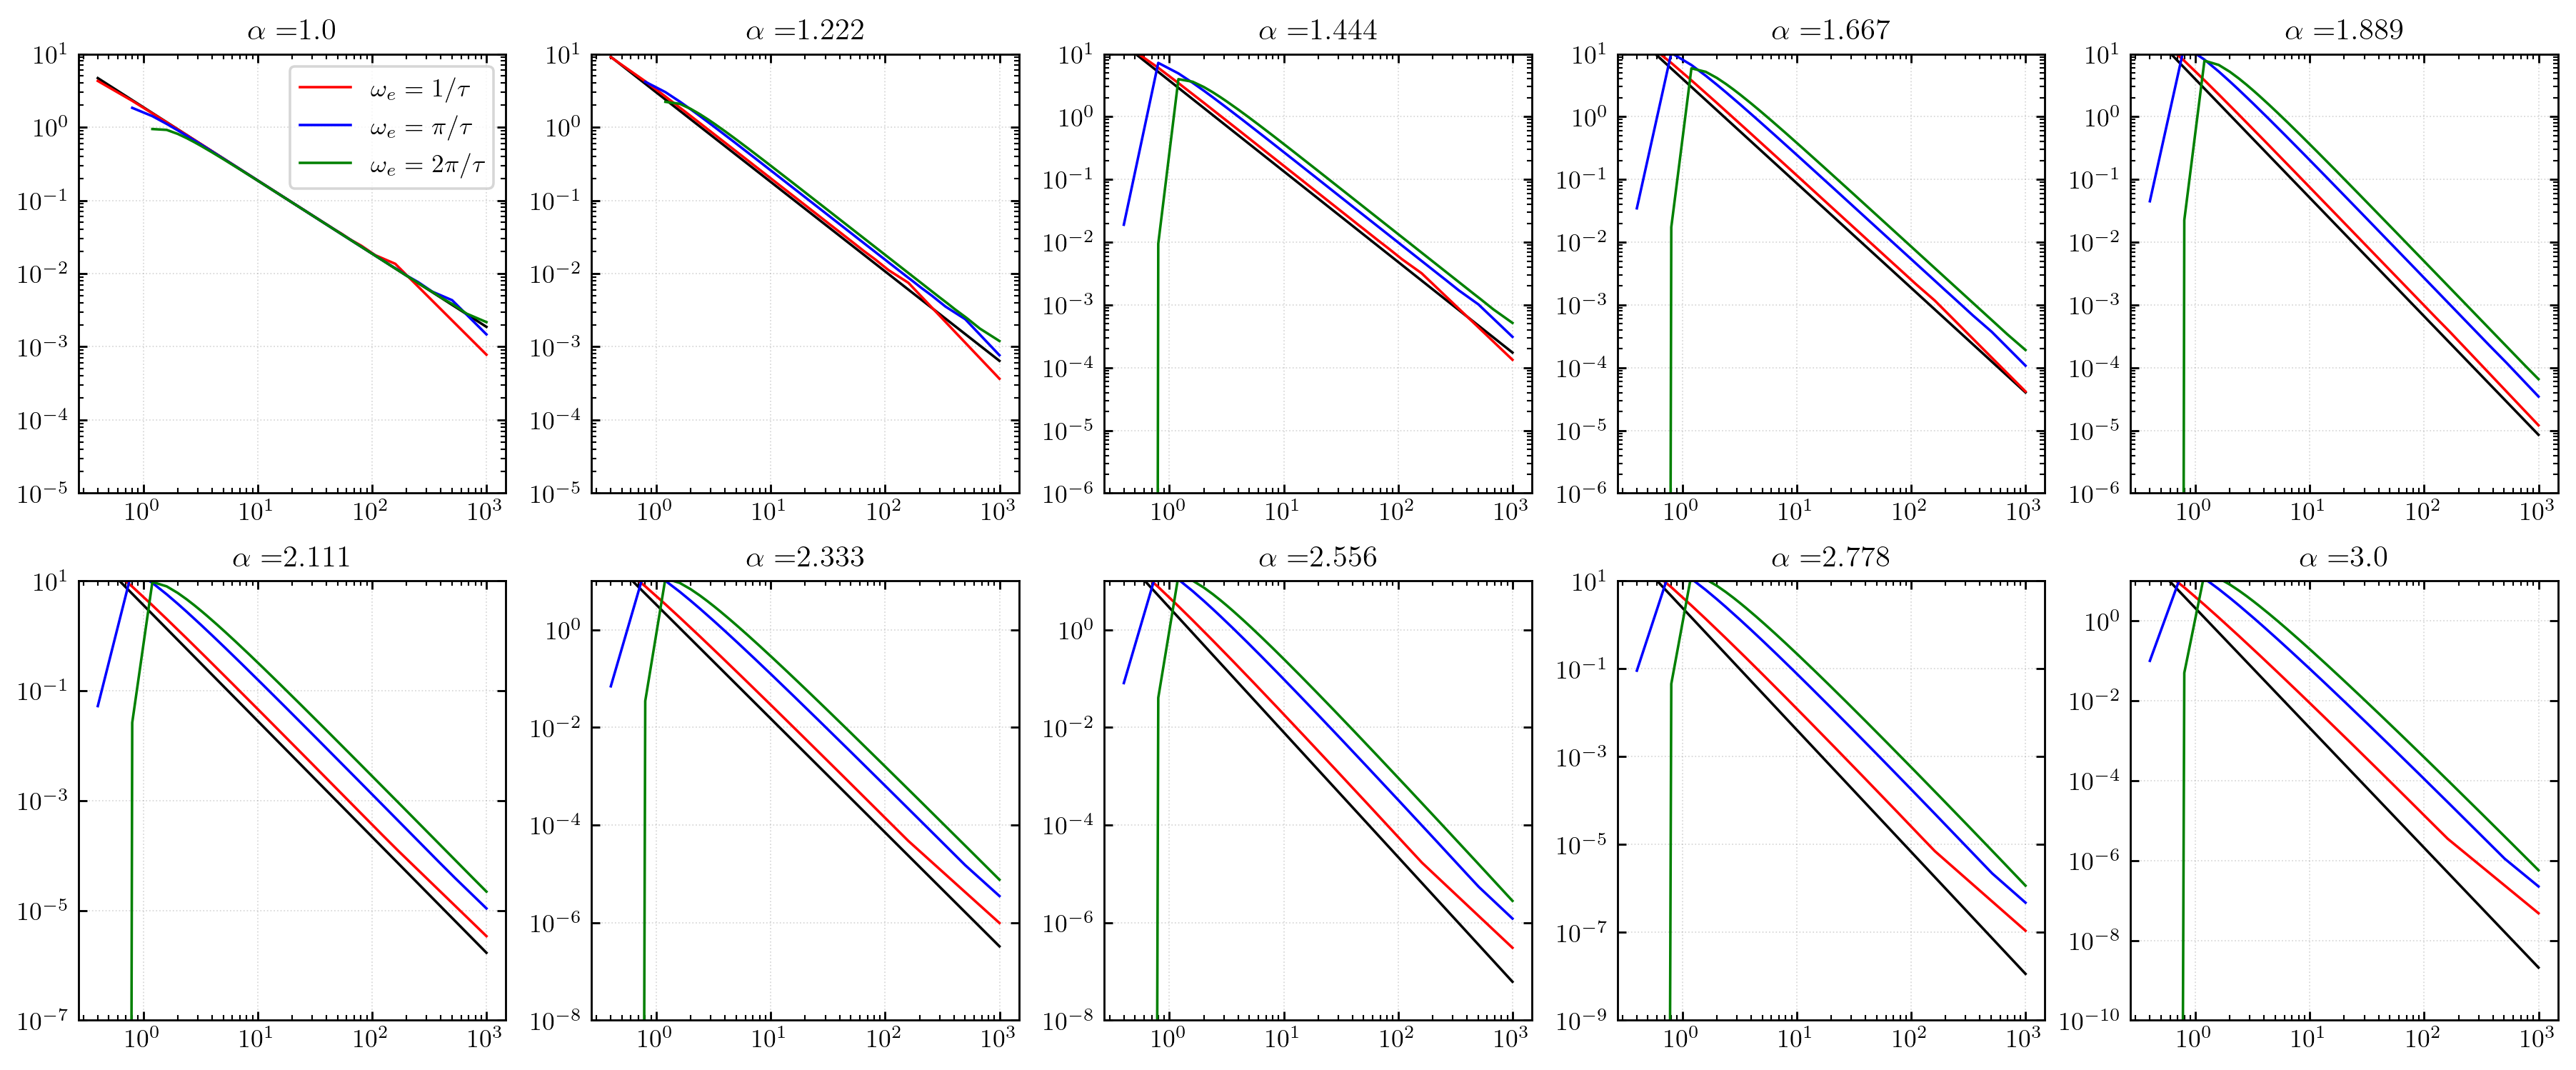

In [8]:

fig, ax = plt.subplots(2, 5, figsize=(3.5*5, 3.5*2), dpi=256)

i = 0
for j in range(2):
    for k in range(5):
        a = alphas[i]

        fek_11 = interpolate(*Especs_11[i], Pspecs[i][0])
        fek_pipi = interpolate(*Especs_pipi[i], Pspecs[i][0])
        fek_2pi2pi = interpolate(*Especs_2pi2pi[i], Pspecs[i][0])
        ax[j][k].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color='black')
        ax[j][k].plot(Pspecs[i][0], fek_11, linewidth=1., color='red')
        ax[j][k].plot(Pspecs[i][0], fek_pipi, linewidth=1., color='blue')
        ax[j][k].plot(Pspecs[i][0], fek_2pi2pi, linewidth=1., color='green')

        ax[j][k].set_title(r'$\alpha=$%s' % -a.round(decimals=3))

        ax[j][k].set_ylim((1e-12, 1e1))

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0][0].plot([], [], linewidth=1., color='red', label=r'$\omega_e = 1/\tau$')
ax[0][0].plot([], [], linewidth=1., color='blue', label=r'$\omega_e = \pi/\tau$')
ax[0][0].plot([], [], linewidth=1., color='green', label=r'$\omega_e = 2 \pi/\tau$')
ax[0][0].legend()

ax[0][0].set_ylim((1e-5, 1e1))
ax[0][1].set_ylim((1e-5, 1e1))
ax[0][2].set_ylim((1e-6, 1e1))
ax[0][3].set_ylim((1e-6, 1e1))
ax[0][4].set_ylim((1e-6, 1e1))

ax[1][0].set_ylim((1e-7, 1e1))
ax[1][1].set_ylim((1e-8, 1e1))
ax[1][2].set_ylim((1e-8, 1e1))
ax[1][3].set_ylim((1e-9, 1e1))
ax[1][4].set_ylim((1e-10, 1e1))


Text(0.5, 1.0, 'SF $\\rightarrow$ ACF')

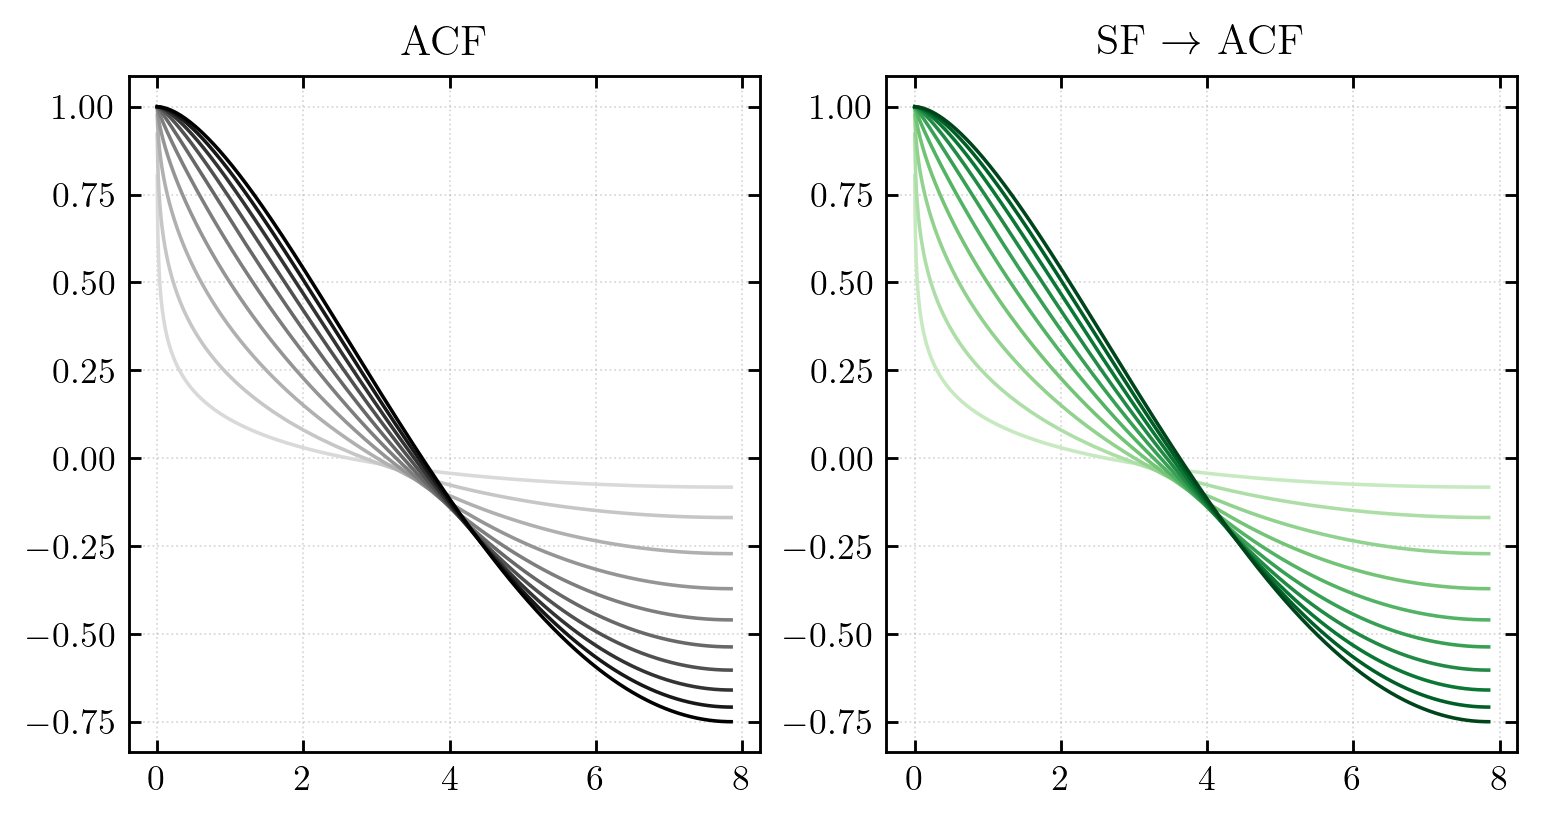

In [9]:
sfacfs = []

for i, a in enumerate(alphas):
    var = 2.*moments.var(fields[i], lenn=phys_dims)
    #var = Ssf[i][1][-1]
    sfacfs.append((Ssf[i][0], (var - Ssf[i][1])/2.))

fig, ax = plt.subplots(1, 2, figsize=(2.*3.5, 3.5), dpi=256)

for i, a in enumerate(alphas):
    ax[0].plot(Sacf[i][0], Sacf[i][1], linewidth=1., color=cols[i])
    ax[1].plot(sfacfs[i][0], sfacfs[i][1], linewidth=1., color=cols3[i])

for axx in ax:
    axx.yaxis.set_ticks_position('both')
    axx.xaxis.set_ticks_position('both')
    axx.tick_params(axis='y', direction='in')
    axx.tick_params(axis='y', direction='in', which='minor')
    axx.tick_params(axis='x', direction='in')
    axx.tick_params(axis='x', direction='in', which='minor')
    axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0].set_title('ACF')
ax[1].set_title('SF $\\rightarrow$ ACF')


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))


True True
True True


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))


True True
True True


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i]

...

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))


True True
True True


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))


True True
True True


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: ComplexWarning: Casting complex values to real discards the imaginary part
  result[vv, i] = stat_func(np.array(bin_map[i]))


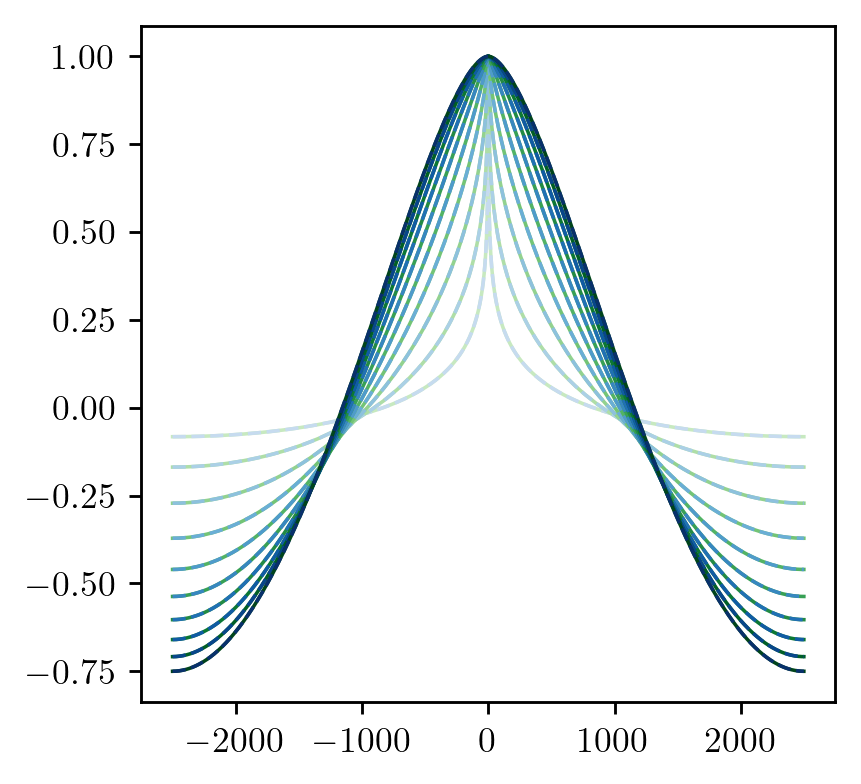

In [10]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

Cspecs = []

realCspecs = []

for i, a in enumerate(alphas):
    n = 2*len(sfacfs[i][1])
    wrong_acf = np.zeros(n+1)
    wrong_acf[:n//2] = sfacfs[i][1][::-1]
    wrong_acf[n//2+1:] = sfacfs[i][1]
    wrong_acf[n//2] = moments.var(fields[i], lenn=phys_dims)
    #wrong_acf[n//2] = np.nanmax(sfacfs[i][1])

    ax.plot(np.arange(-N//2+1, N//2, 1), wrong_acf, color=cols3[i], linewidth=1.)

    kD, fekD = corr_spectra.modal_spectrum(wrong_acf, lenn=[l for l in phys_dims])
    _ko, _feko, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=[l for l in phys_dims],
        ignore_nan=True, nan_small=True)#, max_bin=np.pi*N/(L), min_bin=dk)
    Cspecs.append((_ko, _feko))

    cut_acf = statfunc_base.cut_at_lag(all_acf[i], N//2)
    kD, fekD = corr_spectra.modal_spectrum(cut_acf, lenn=phys_dims)
    _ko, _feko, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims,
        ignore_nan=True, nan_small=True)#, max_bin=np.pi*N/L, min_bin=dk)
    realCspecs.append((_ko, _feko))

    ax.plot(np.arange(-N//2+1, N//2, 1), cut_acf[1:N], color=cols2[i], linewidth=1., linestyle='--')

    print(np.allclose(wrong_acf, cut_acf[1:N]), np.allclose(wrong_acf[::-1], cut_acf[1:N][::-1]))



(1e-08, 100.0)

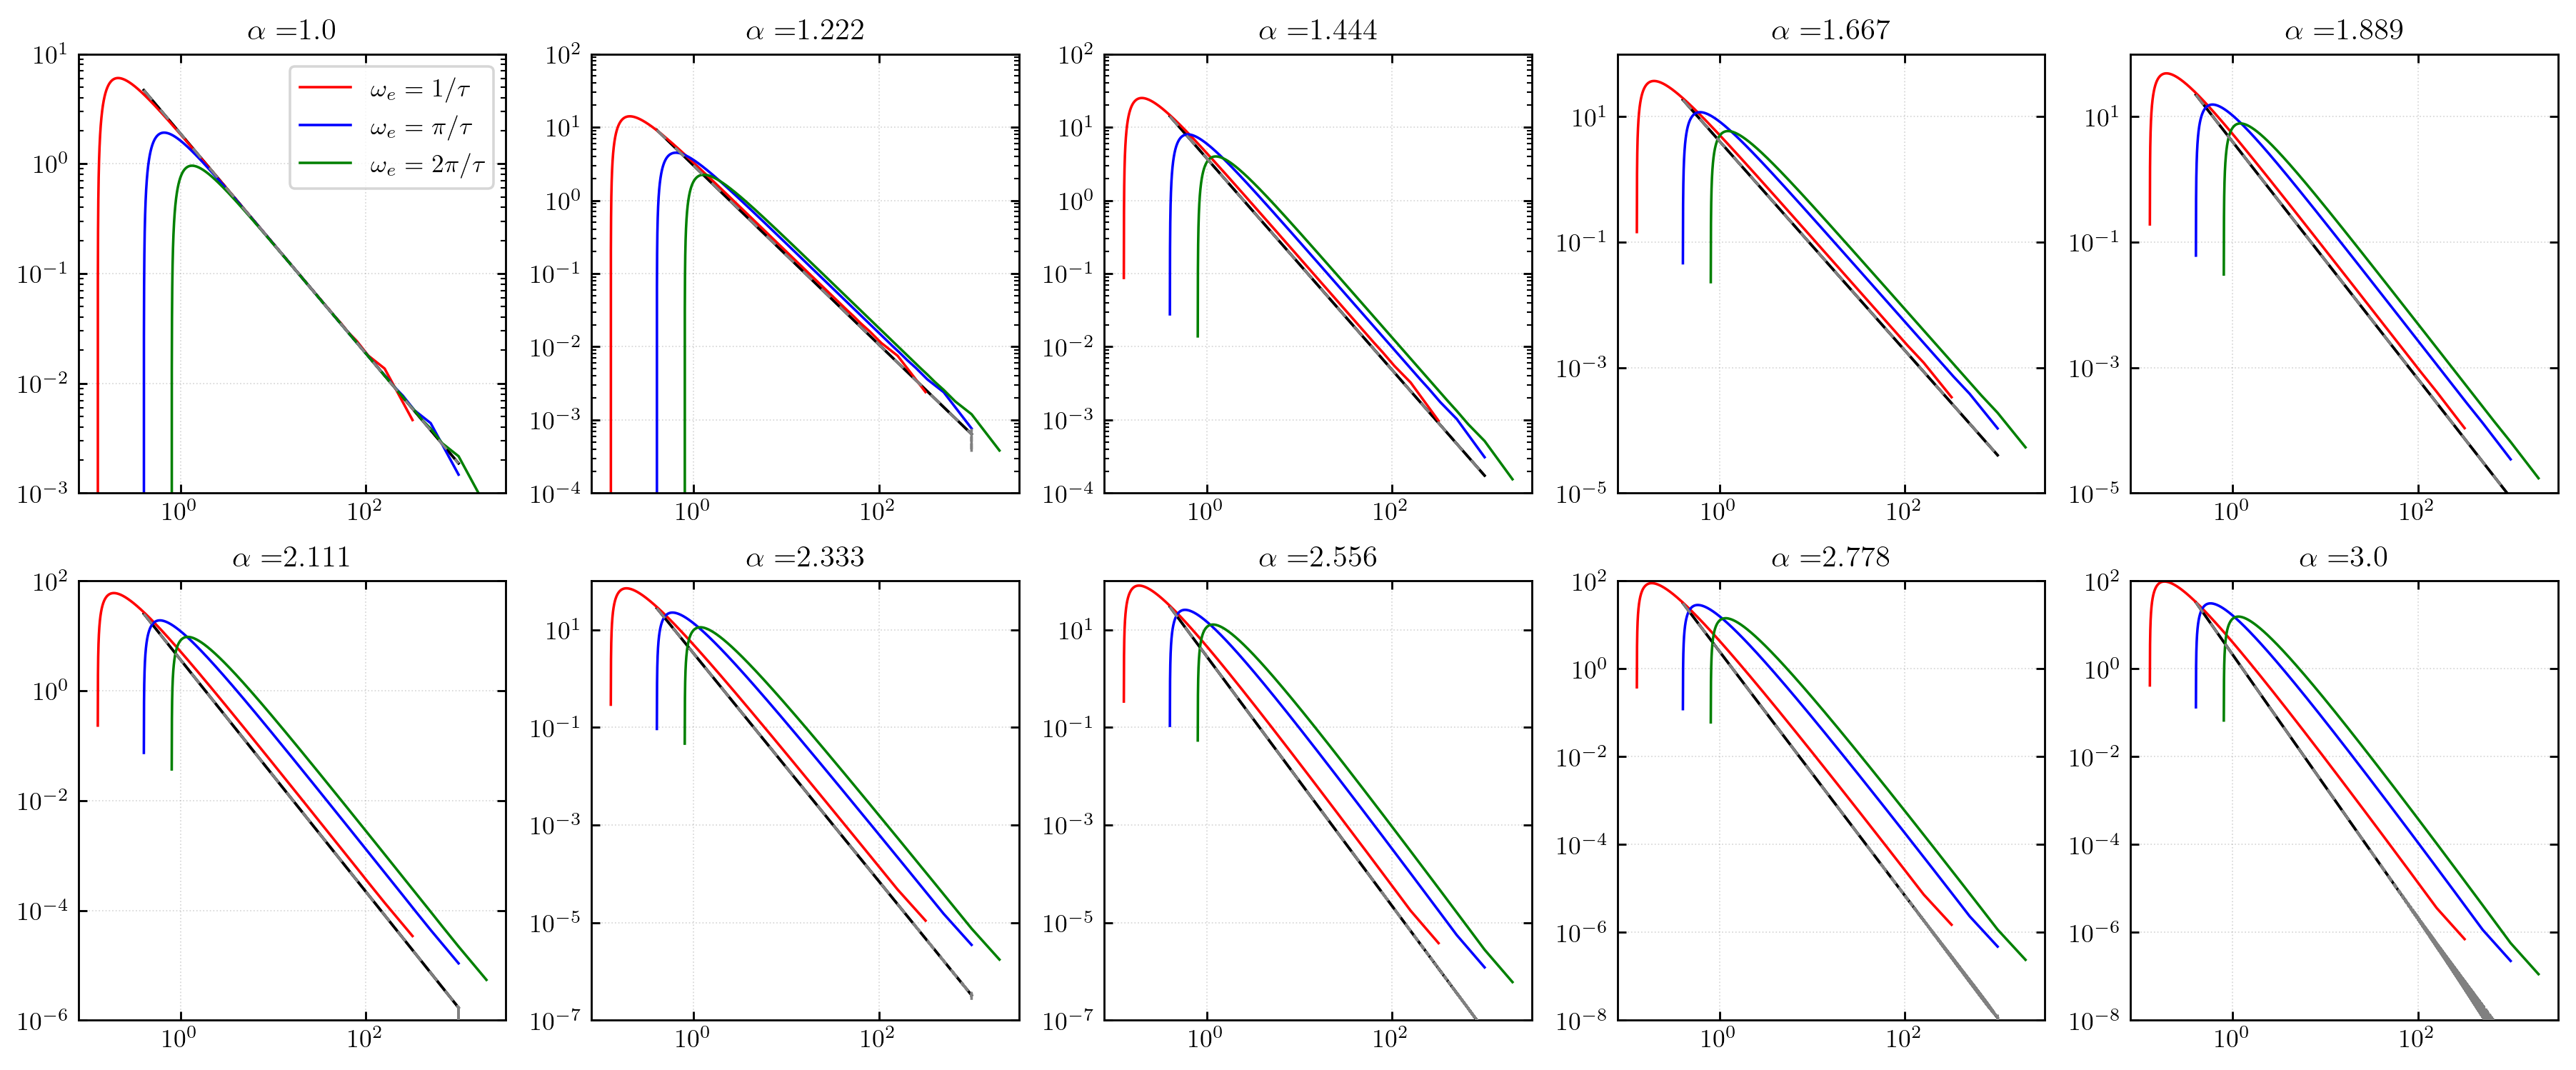

In [13]:

fig, ax = plt.subplots(2, 5, figsize=(3.5*5, 3.5*2), dpi=256)

i = 0
for j in range(2):
    for k in range(5):
        a = alphas[i]

        #fek_11 = interpolate(*Especs_11[i], Cspecs[i][0])
        #fek_pipi = interpolate(*Especs_pipi[i], Cspecs[i][0])
        #fek_2pi2pi = interpolate(*Especs_2pi2pi[i], Cspecs[i][0])
        ax[j][k].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color='black', zorder=0)
        ax[j][k].plot(Cspecs[i][0], Cspecs[i][1], linewidth=1., color='gray', linestyle=(0,(5,5)), zorder=4)
        #ax[j][k].plot(realCspecs[i][0], realCspecs[i][1], linewidth=1., color='gray', linestyle=':', zorder=5)
        # ax[j][k].plot(Cspecs[i][0], fek_11, linewidth=1., color='red')
        # ax[j][k].plot(Cspecs[i][0], fek_pipi, linewidth=1., color='blue')
        # ax[j][k].plot(Cspecs[i][0], fek_2pi2pi, linewidth=1., color='green')

        ax[j][k].plot(Pspecs[i][0], Pspecs[i][1], linewidth=1., color='black')
        ax[j][k].plot(Especs_11[i][0], Especs_11[i][1], linewidth=1., color='red')
        ax[j][k].plot(Especs_pipi[i][0], Especs_pipi[i][1], linewidth=1., color='blue')
        ax[j][k].plot(Especs_2pi2pi[i][0], Especs_2pi2pi[i][1], linewidth=1., color='green')


        ax[j][k].set_title(r'$\alpha=$%s' % -a.round(decimals=3))

        ax[j][k].set_ylim((1e-12, 1e1))

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0][0].plot([], [], linewidth=1., color='red', label=r'$\omega_e = 1/\tau$')
ax[0][0].plot([], [], linewidth=1., color='blue', label=r'$\omega_e = \pi/\tau$')
ax[0][0].plot([], [], linewidth=1., color='green', label=r'$\omega_e = 2 \pi/\tau$')
ax[0][0].legend()

ax[0][0].set_ylim((1e-3, 1e1))
ax[0][1].set_ylim((1e-4, 1e2))
ax[0][2].set_ylim((1e-4, 1e2))
ax[0][3].set_ylim((1e-5, 1e2))
ax[0][4].set_ylim((1e-5, 1e2))

ax[1][0].set_ylim((1e-6, 1e2))
ax[1][1].set_ylim((1e-7, 1e2))
ax[1][2].set_ylim((1e-7, 1e2))
ax[1][3].set_ylim((1e-8, 1e2))
ax[1][4].set_ylim((1e-8, 1e2))
